# 03 - Z-score / Modified Z-score Detector (Step 3)

**Purpose:** implement the point-anomaly corner of the five-method
comparison — standard Z-score and Modified (MAD-based) Z-score, applied
independently to each of the three sensor channels at every Step 0
in-scope station. This step also establishes the fixed output schema
(`station`, `sensor`, `timestamp`, `method`, `flagged`, `score`) that every
subsequent detector (Steps 4-6) must conform to, since Step 7's whole
analysis depends on aligning all methods' flagged sets at matching
station/sensor/timestamp combinations — retrofitting a shared schema after
five notebooks are independently built would be far more costly than fixing
it now, before any other detector exists.

This method is not a baseline to be "beaten" — there is no best-method
claim anywhere in this project. Its only role is to be one of five
comparable inputs to Step 7's agreement/disagreement analysis, representing
the "does a single reading look wrong on its own" corner of the taxonomy.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from uema.detect import (
    MODIFIED_Z_THRESHOLD,
    SCHEMA_COLUMNS,
    WINDOW_BINS,
    Z_THRESHOLD,
    build_detection_table,
    hour_of_day_zscore,
    rolling_modified_zscore,
    rolling_zscore,
)
from uema.silver import consolidate_stations, fill_gaps
from uema.style import PALETTE, PALETTE_ORDER, apply_style, pretty_label

apply_style()

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 100)

REPORT_DIR = Path("..") / "reports" / "data_audit"
DETECT_DIR = Path("..") / "reports" / "detections"
DETECT_DIR.mkdir(parents=True, exist_ok=True)


## Recap and data prep

Same in-scope station roster as Steps 1-2 (`station_recommendation.csv`, GO
+ CONDITIONAL-GO, 12 of 13 stations — no station list hardcoded), each
consolidated onto its own joint-span 10-minute grid and short-gap-filled the
same way (`uema.silver.consolidate_stations` + `fill_gaps`, <=6h linear
bridge). Longer gaps are left as `NaN` and simply produce no detection row
at that timestamp for any method (see `build_detection_table`'s docstring)
rather than a fabricated "not flagged" result.


In [2]:
recommendation = pd.read_csv(REPORT_DIR / "station_recommendation.csv", index_col="station")
station_frames = consolidate_stations(recommendation)
station_frames = {
    station: fill_gaps(df.resample("10min").mean(), max_gap="6h")
    for station, df in station_frames.items()
}
sorted(station_frames)


['recinto-esparza',
 'recinto-santa-cruz',
 'sede-atlantico_turrialba',
 'sede-caribe_limon',
 'sede-central_finca-1',
 'sede-central_finca-2',
 'sede-central_finca-3',
 'sede-central_losic-norte-1',
 'sede-central_losic-norte-2',
 'sede-central_sabanilla',
 'sede-guanacaste_liberia',
 'sede-sur_golfito']

## Methodology

**Rolling, not whole-history.** `pressure` and especially
`luminous_intensity` are strongly non-stationary — lux swings from ~0 at
night to tens of thousands of lux at midday, so a Z-score against each
station's whole-history mean/std would mostly just rediscover "is it
daytime," not surface a genuine point deviation. Both Z-score and Modified
Z-score are computed as a **6-hour centered rolling window** (36 bins at
10-minute resolution, `uema.detect.WINDOW_BINS`) instead — the same window
Step 2's own pressure point-anomaly criterion used ("deviation from the
station's surrounding 6h rolling mean"), applied uniformly to all three
sensors here for consistency across the detector.

**Scale flooring.** A local 6h window's std (or MAD) can collapse to near
zero — a calm, rain-free precipitation window, or a still, clear-sky lux
stretch — which would blow up the z-score for any small subsequent wiggle.
Both methods floor the local scale at 10% of the station/sensor's
whole-history scale (`GLOBAL_FLOOR_FRAC`) before dividing, so a deviation
still has to be large relative to how that sensor normally varies, not just
locally quiet. `precipitation`'s zero-inflation (over half of all 10-minute
bins are exactly 0.0mm at most stations) pushed this further: even the
*global* MAD is exactly 0 for a zero-inflated series, so `uema.detect`
falls back to the whole-history standard deviation as the floor anchor
specifically when the global MAD itself is degenerate — documented in
`rolling_modified_zscore`'s docstring, found and fixed during development
of this notebook (an earlier version silently produced almost no scored
precipitation rows because the floor was flooring at 0).

**Thresholds** (no labels exist to tune against, so both are the standard
literature convention rather than something fit to this data): `|z| > 3`
for standard Z-score, `|modified z| > 3.5` for Modified Z-score (Iglewicz &
Hoaglin, 1993).

**Context-conditioned variant — `luminous_intensity` only.** Step 2's
contextual-anomaly criterion for `luminous_intensity` is a plain per-hour
comparison ("a value unremarkable in the full distribution but wrong for
its specific hour") — exactly what `uema.detect.hour_of_day_zscore`
computes: each reading's Z-score against that station's own historical
distribution *for that hour-of-day*, not a rolling local window. Step 2's
`pressure` and `precipitation` contextual criteria are cross-variable
(lagged pressure-lux coupling; daytime-conditioned precipitation-lux
coupling) and are **not** captured by a univariate per-hour Z-score, so no
context-conditioned variant is computed for those two sensors here — that
would need a method that looks at two sensors jointly, which is out of
scope for the Z-score family.


In [3]:
SENSORS = ("pressure", "precipitation", "luminous_intensity")

tables = []
for station, df10 in station_frames.items():
    for sensor in SENSORS:
        series = df10[sensor]

        z = rolling_zscore(series)
        tables.append(build_detection_table(z, station, sensor, "z_score", Z_THRESHOLD))

        mz = rolling_modified_zscore(series)
        tables.append(
            build_detection_table(mz, station, sensor, "modified_z_score", MODIFIED_Z_THRESHOLD)
        )

    hz = hour_of_day_zscore(df10["luminous_intensity"])
    tables.append(
        build_detection_table(
            hz, station, "luminous_intensity", "z_score_context_hour", Z_THRESHOLD
        )
    )

detections = pd.concat(tables, ignore_index=True)
assert list(detections.columns) == SCHEMA_COLUMNS
detections.to_parquet(DETECT_DIR / "step3_zscore_family.parquet", index=False)
detections.shape


(4466190, 6)

## Flagged-rate summary

Per station x sensor x method: how many timestamps were scored, how many
flagged, and the flagged rate. Saved as a small tracked CSV
(`reports/detections/step3_summary.csv`) — the full per-timestamp
detection table (`step3_zscore_family.parquet`) is bulky and fully
reproducible by re-running this notebook, so it's gitignored the same way
Step 1's per-station CCF/correlation CSVs are.


In [4]:
summary = (
    detections.groupby(["station", "sensor", "method"])
    .agg(n_scored=("flagged", "size"), n_flagged=("flagged", "sum"))
    .assign(flagged_rate=lambda d: d["n_flagged"] / d["n_scored"])
    .reset_index()
)
summary.to_csv(DETECT_DIR / "step3_summary.csv", index=False)

summary.pivot_table(index=["station", "sensor"], columns="method", values="flagged_rate")


method                                         modified_z_score   z_score  z_score_context_hour
station                    sensor                                                              
recinto-esparza            luminous_intensity          0.021010  0.000068              0.005485
                           precipitation               0.021238  0.005205                   NaN
                           pressure                    0.038291  0.000011                   NaN
recinto-santa-cruz         luminous_intensity          0.015041  0.000068              0.003934
                           precipitation               0.008895  0.002488                   NaN
                           pressure                    0.026215  0.000000                   NaN
sede-atlantico_turrialba   luminous_intensity          0.022119  0.000042              0.004403
                           precipitation               0.045283  0.009415                   NaN
                           pressure                    0.012178  0.000010                   NaN
sede-caribe_limon          luminous_intensity          0.034812  0.000358              0.007118
                           precipitation               0.040565  0.009304                   NaN
                           pressure                    0.024281  0.000000                   NaN
sede-central_finca-1       luminous_intensity          0.033557  0.000336              0.005692
                           precipitation               0.015164  0.003518                   NaN
                           pressure                    0.046648  0.000000                   NaN
sede-central_finca-2       luminous_intensity          0.024700  0.000361              0.013507
                           precipitation               0.018662  0.004502                   NaN
                           pressure                    0.042434  0.000149                   NaN
sede-central_finca-3       luminous_intensity          0.038413  0.000465              0.011292
                           precipitation               0.017135  0.004004                   NaN
                           pressure                    0.037198  0.000036                   NaN
sede-central_losic-norte-1 luminous_intensity          0.021532  0.000000              0.008927
                           precipitation               0.025813  0.005067                   NaN
                           pressure                    0.042013  0.000277                   NaN
sede-central_losic-norte-2 luminous_intensity          0.027348  0.000081              0.007128
                           precipitation               0.011914  0.002979                   NaN
                           pressure                    0.028813  0.000081                   NaN
sede-central_sabanilla     luminous_intensity          0.022705  0.000388              0.010156
                           precipitation               0.032163  0.006138                   NaN
                           pressure                    0.041594  0.000000                   NaN
sede-guanacaste_liberia    luminous_intensity          0.022526  0.000063              0.005940
                           precipitation               0.002245  0.002424                   NaN
                           pressure                    0.038447  0.000000                   NaN
sede-sur_golfito           luminous_intensity          0.024368  0.000051              0.004459
                           precipitation               0.035442  0.008417                   NaN
                           pressure                    0.020845  0.000013                   NaN

Standard Z-score comes back consistently far more conservative than
Modified Z-score across every station/sensor — expected, not a bug: `mean`
and `std` are themselves pulled by the same extreme points a detector is
trying to catch, diluting the score, while `median`/MAD stay robust to
them. This is exactly why the plan calls Modified Z-score a cross-check
against the standard version rather than a redundant duplicate — the two
methods' disagreement with *each other* is itself informative going into
Step 7, before even comparing against the other four methods.


## Sanity-check plots

A handful of the most confidently-flagged episodes (largest `|score|`) per
sensor, standard Z-score only, plotted in context — a check that the
detector is catching genuinely irregular episodes and not some systematic
artifact (e.g. every gap edge, or every sunrise), before trusting this
table as an input to Step 7.


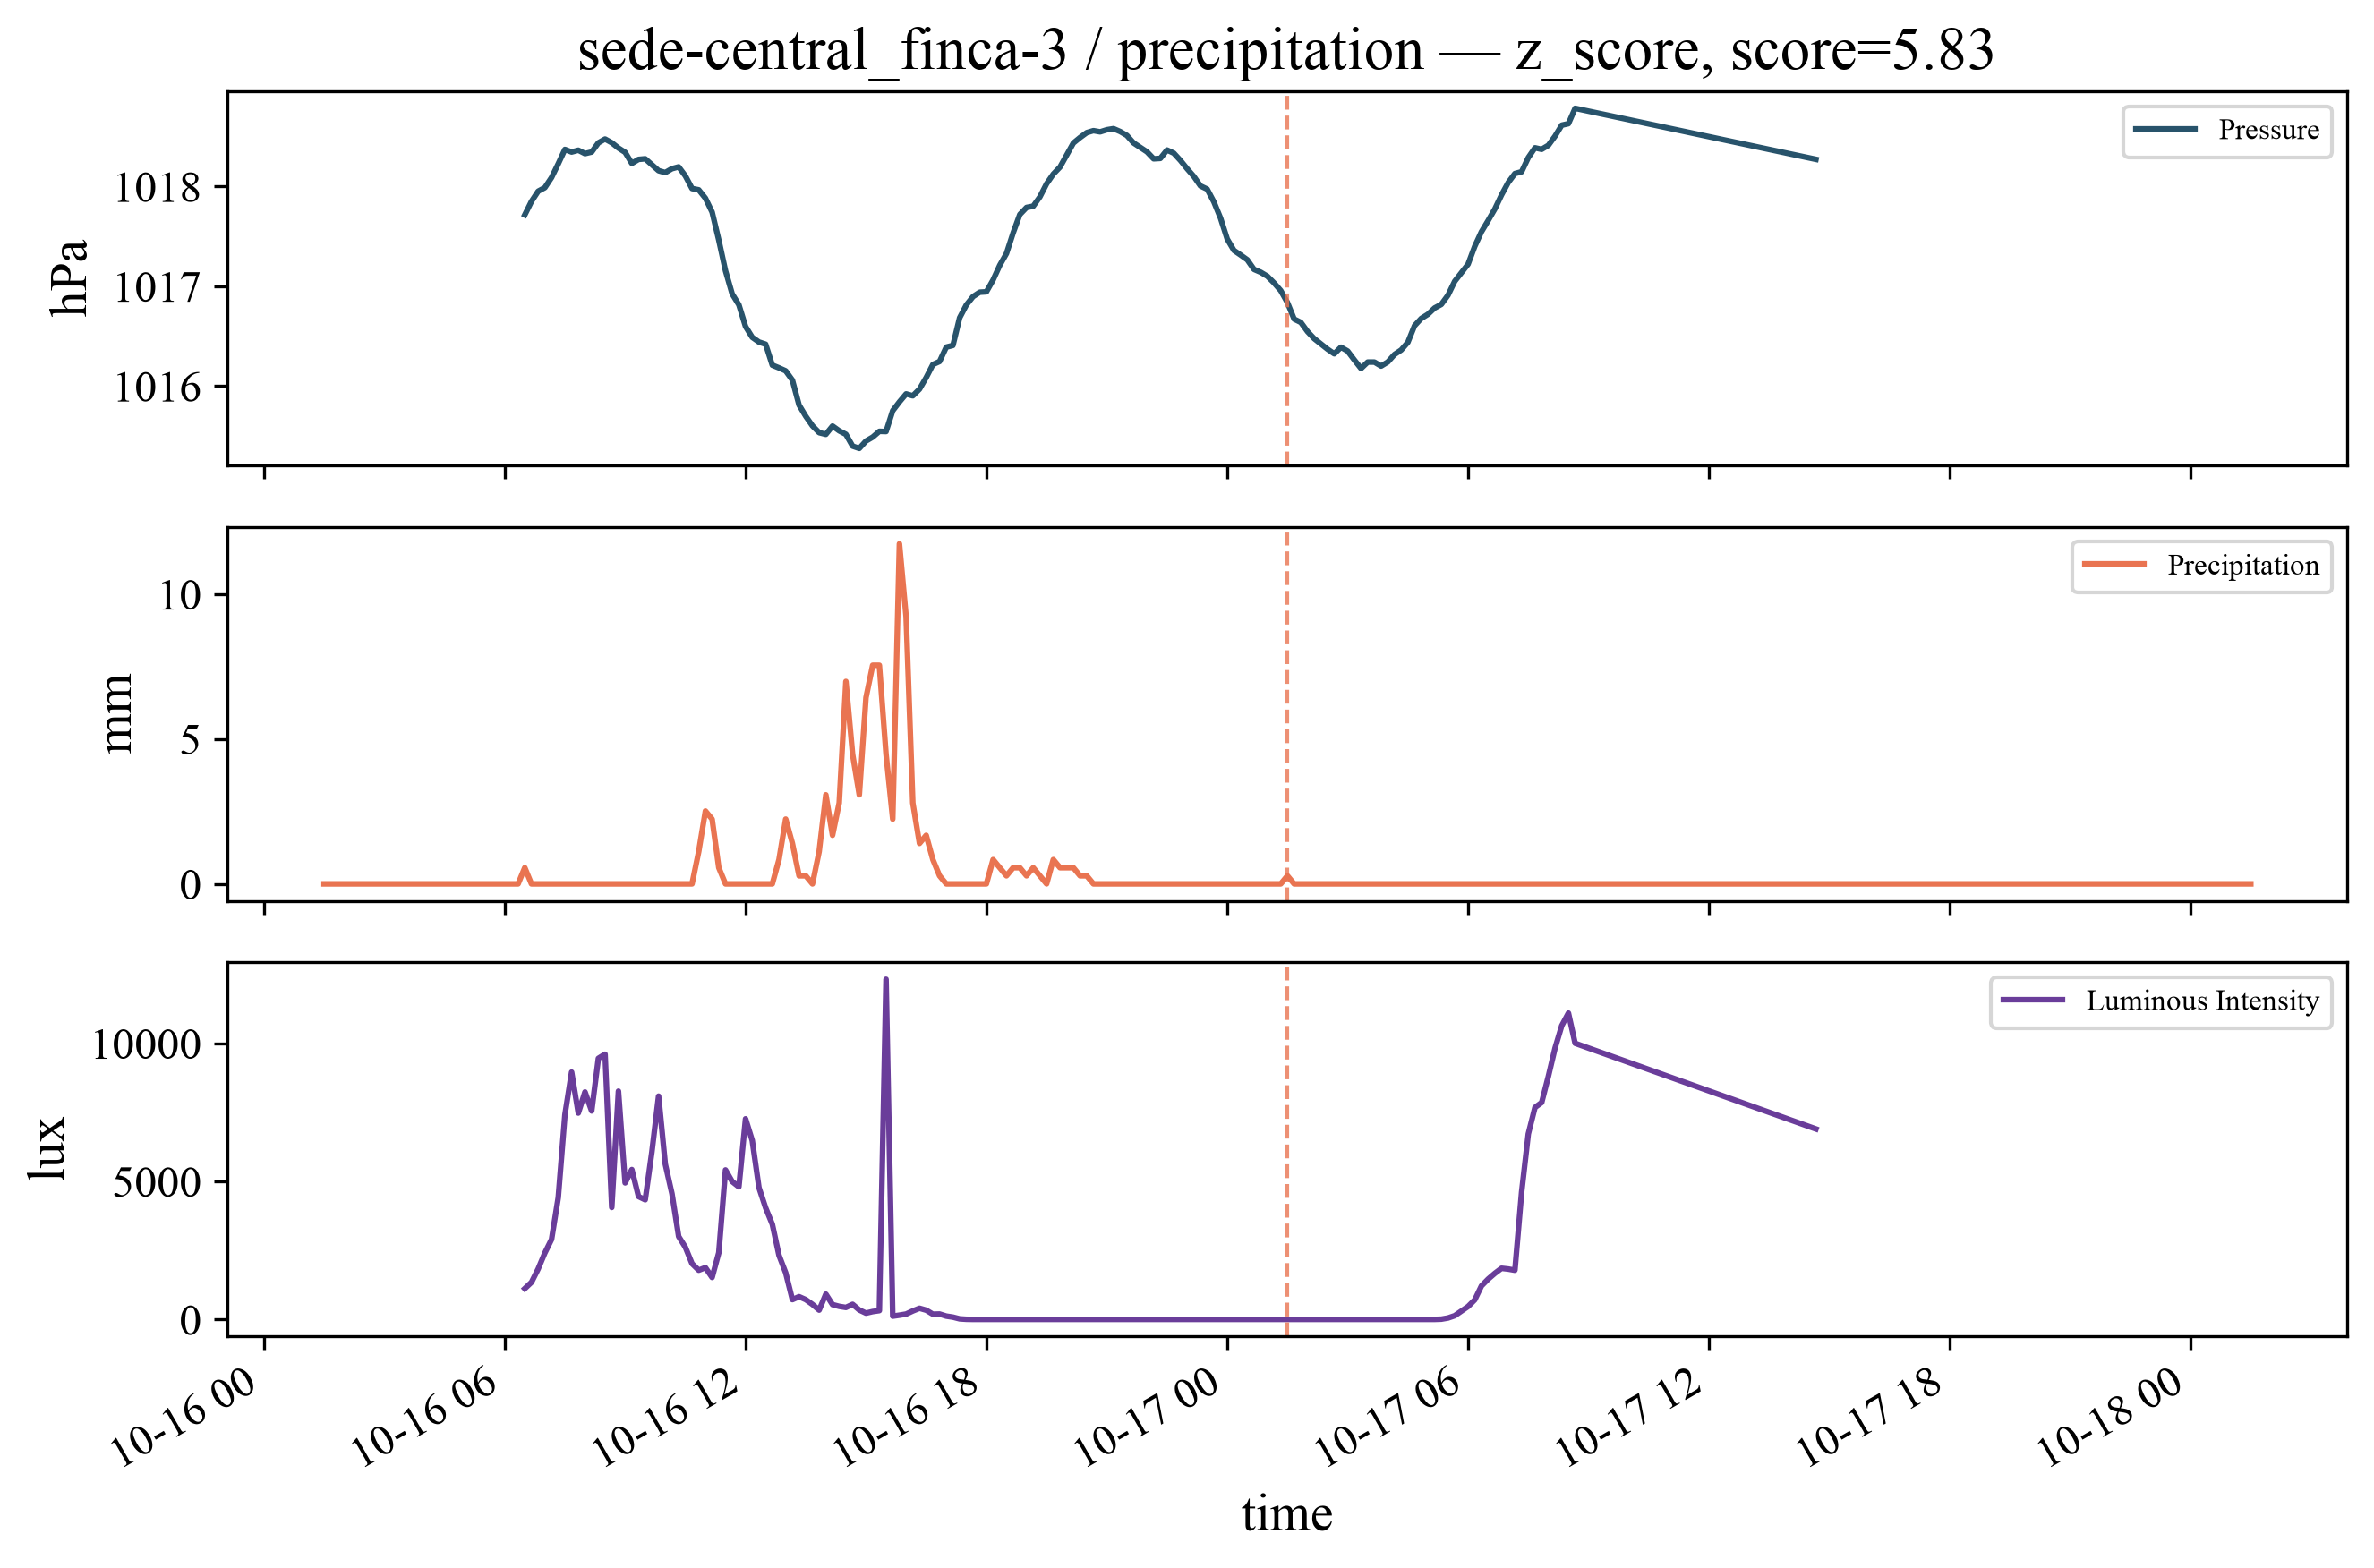

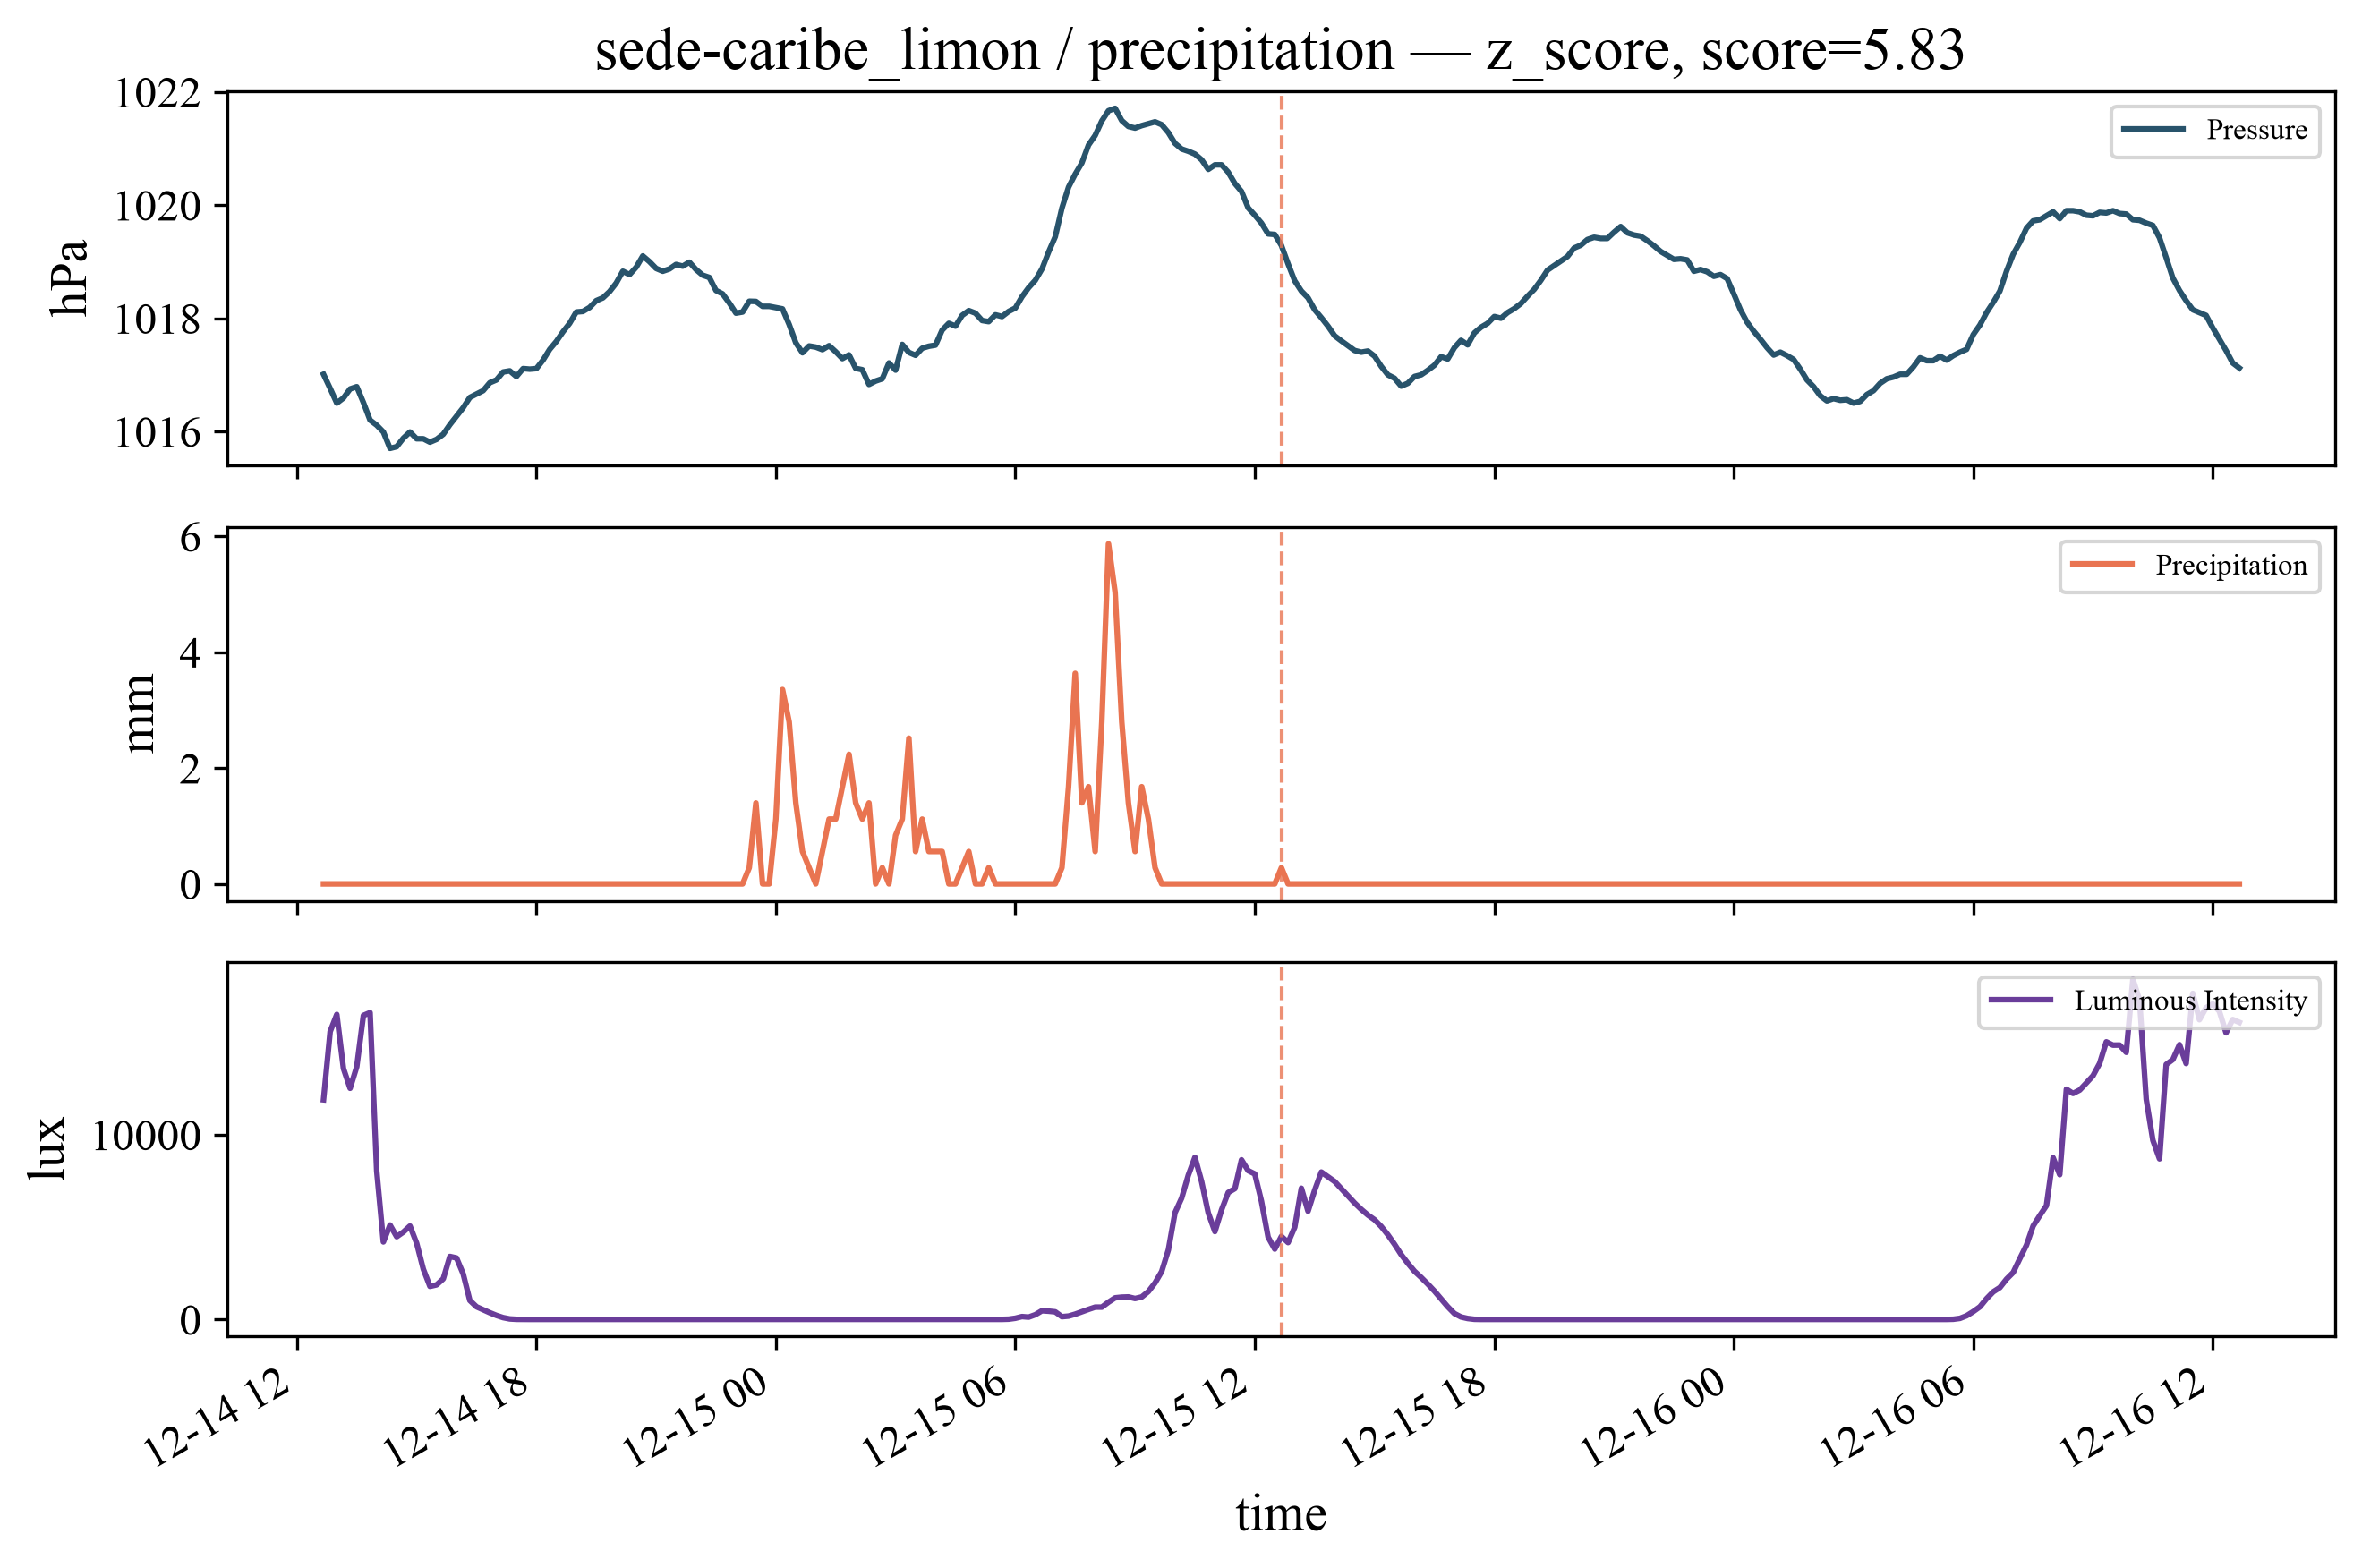

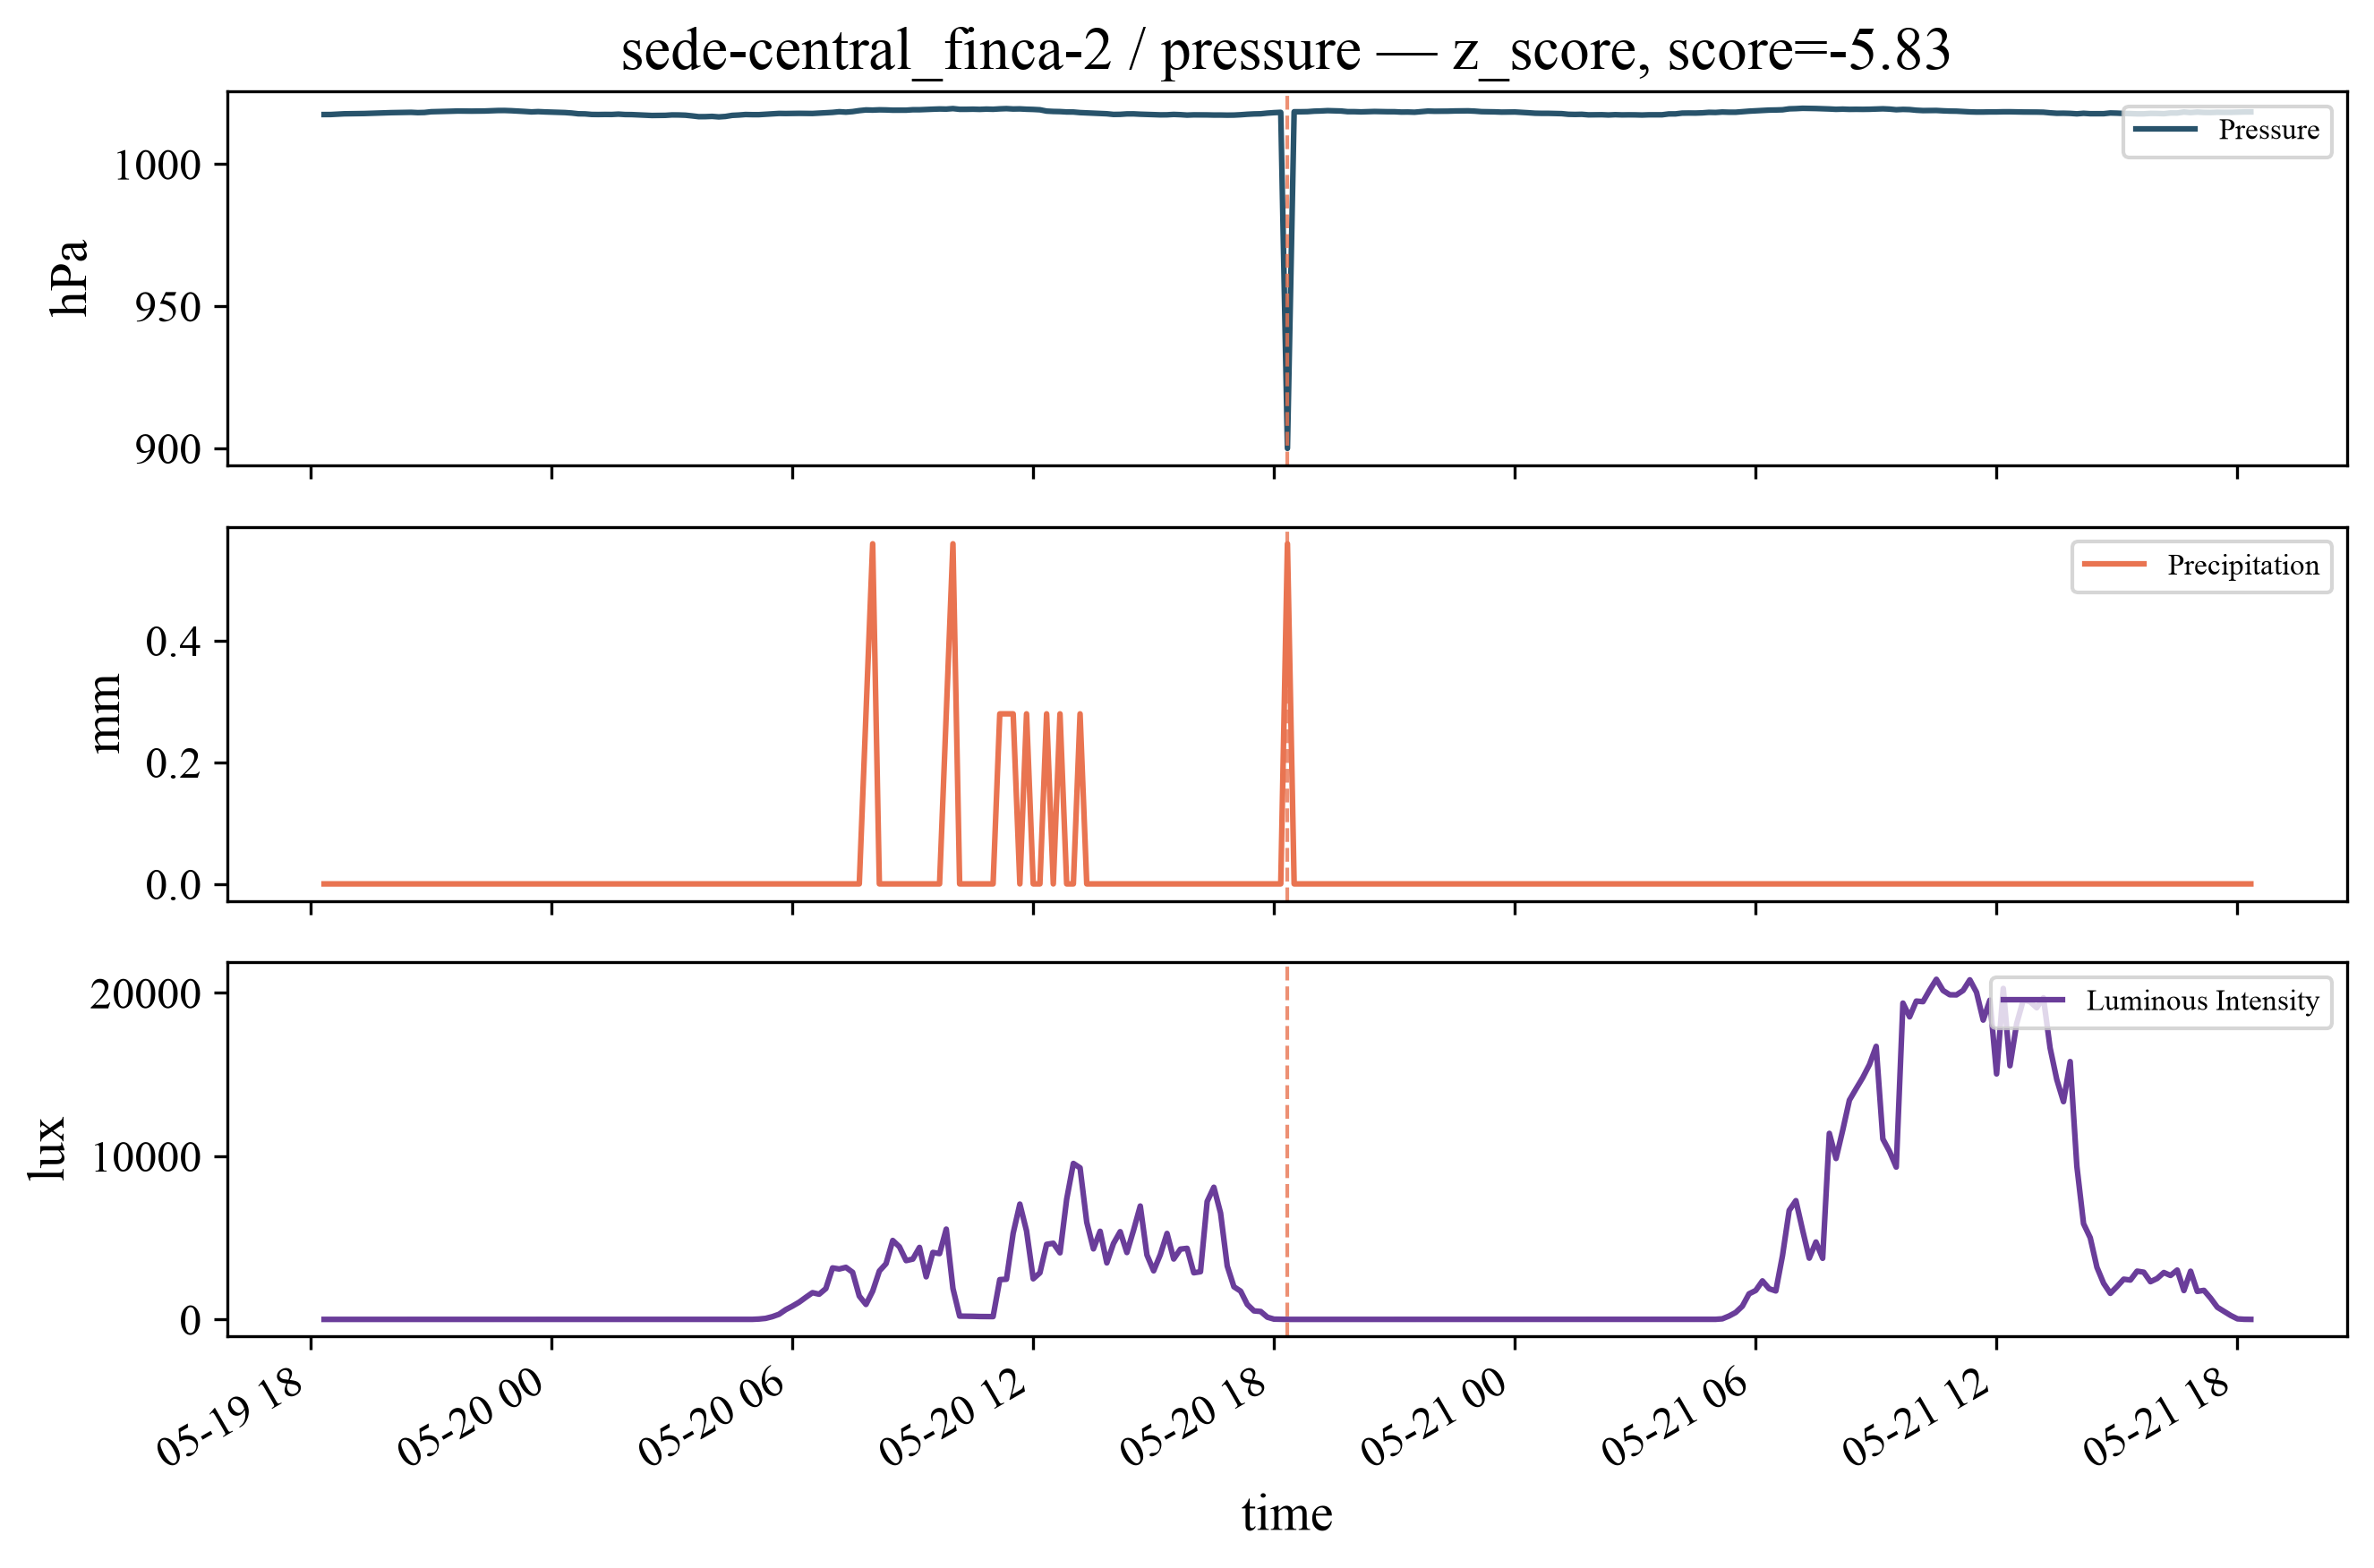

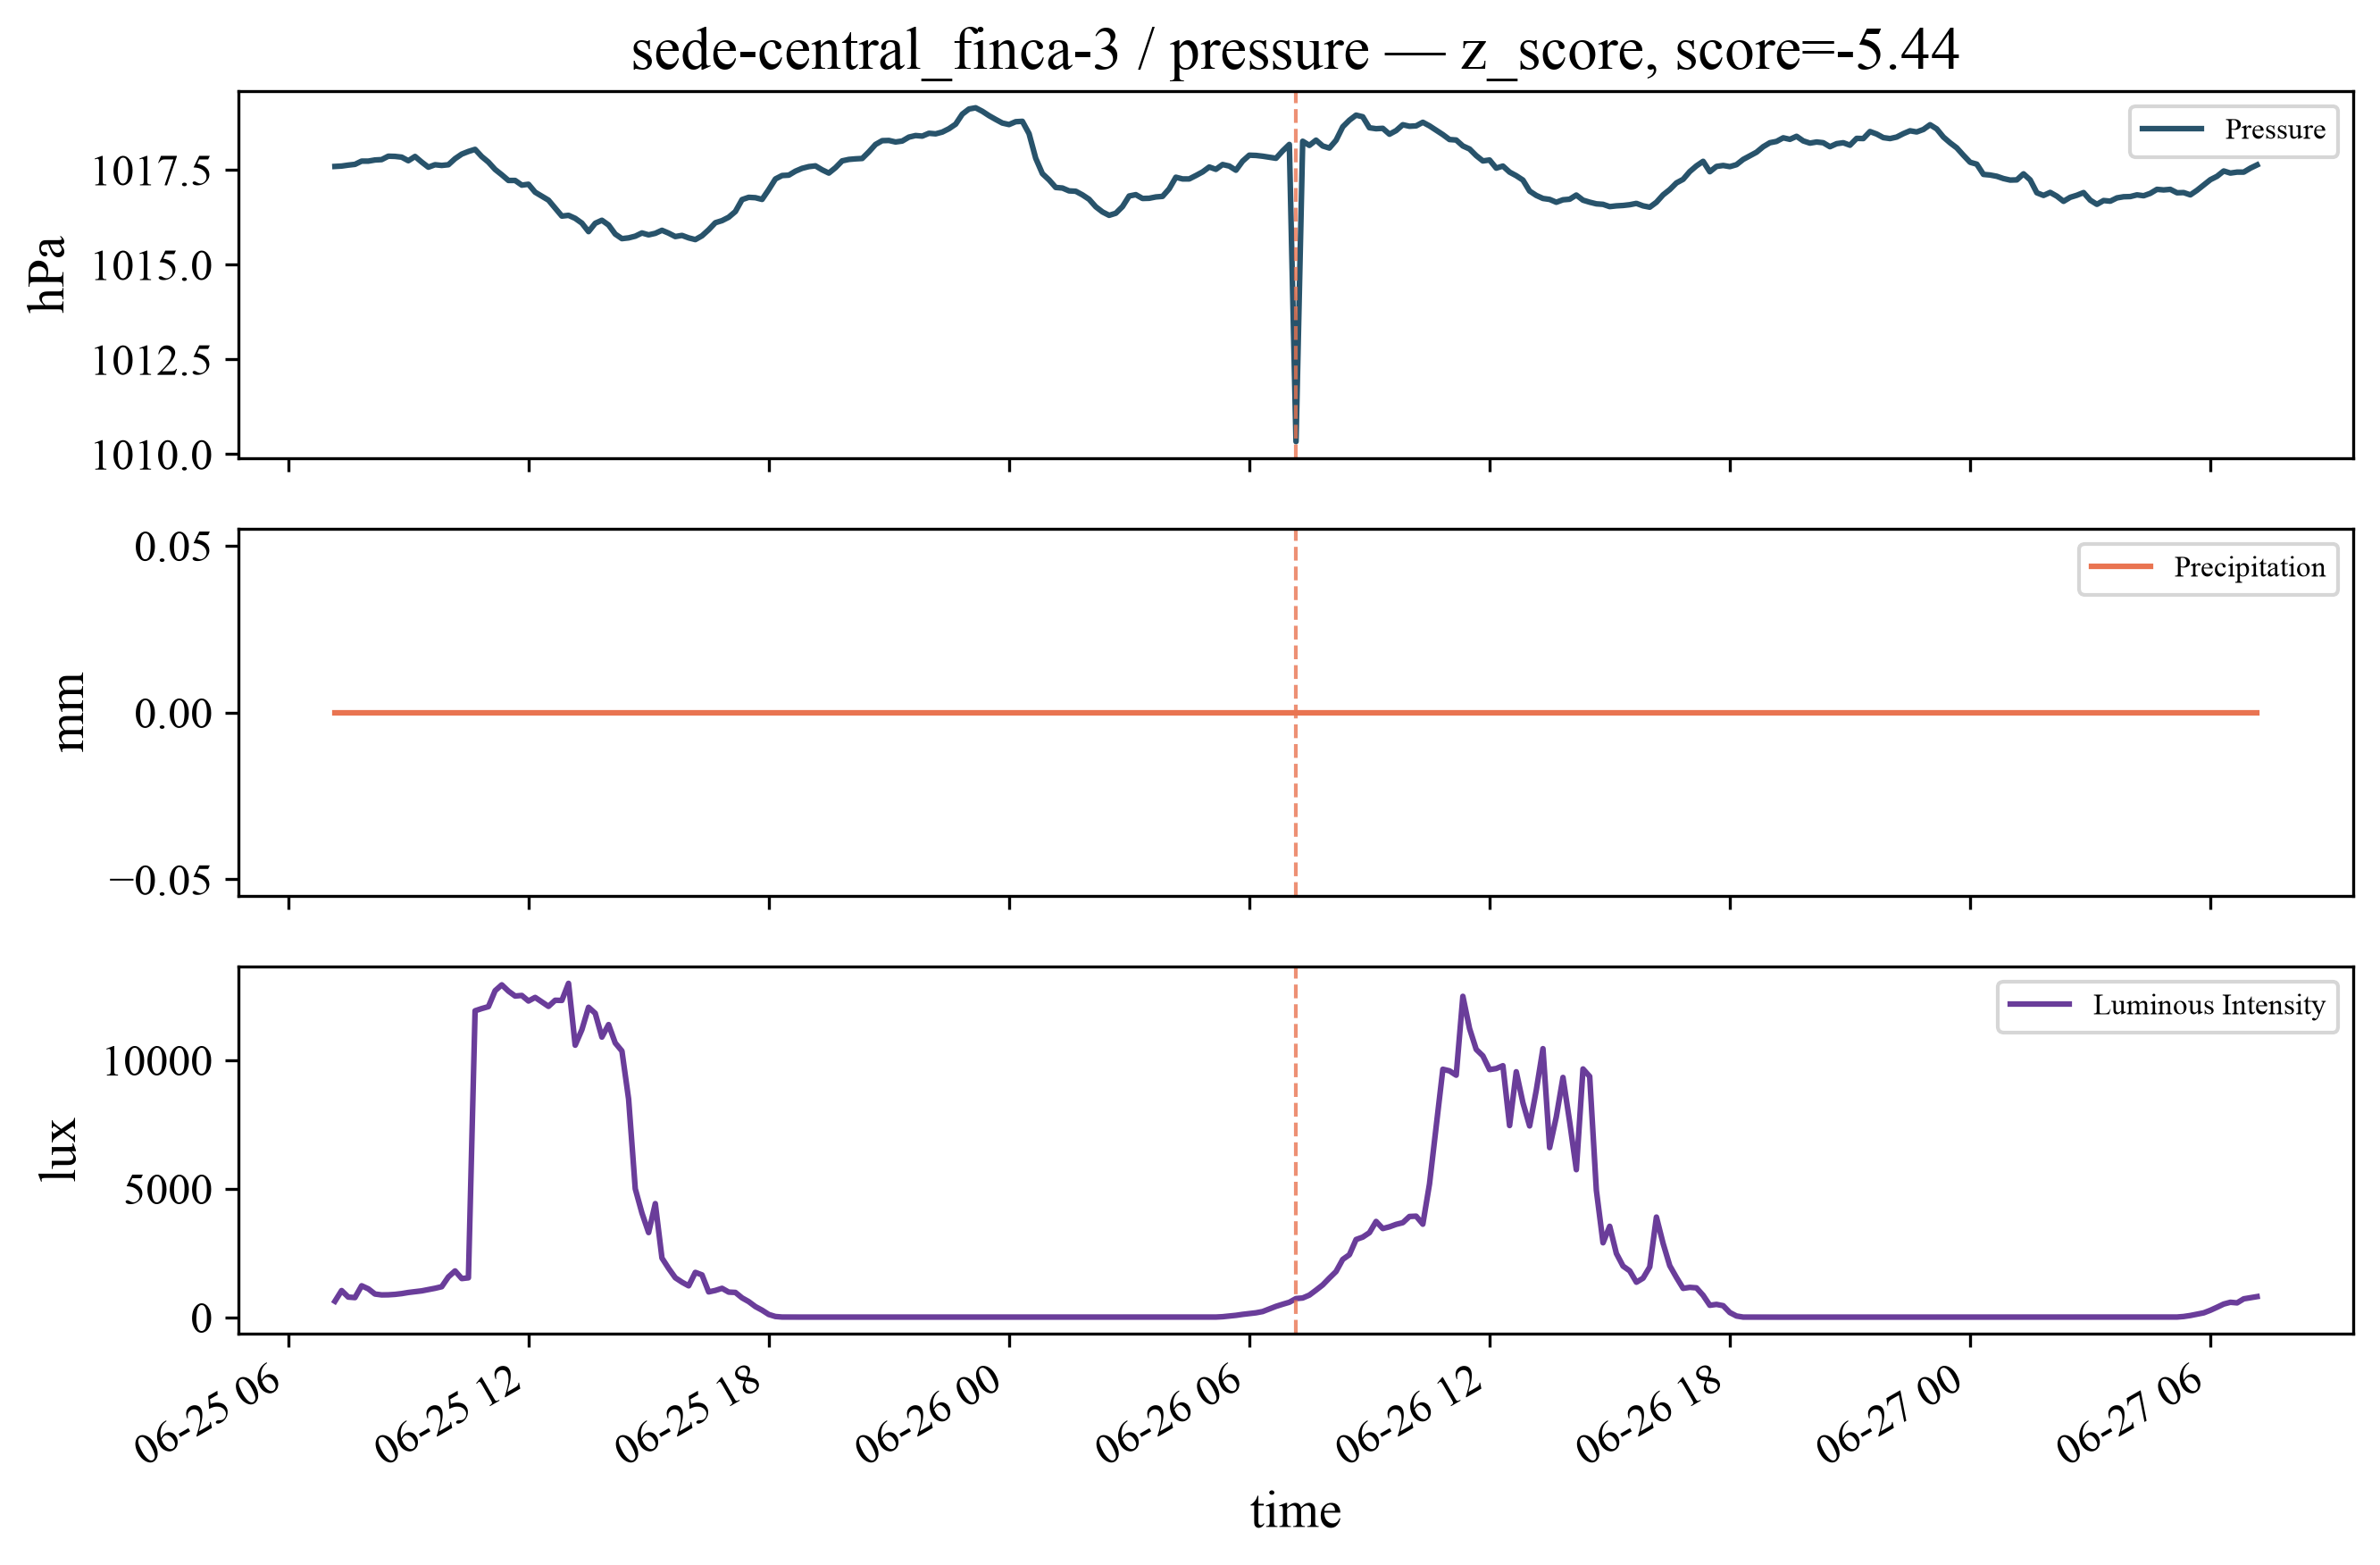

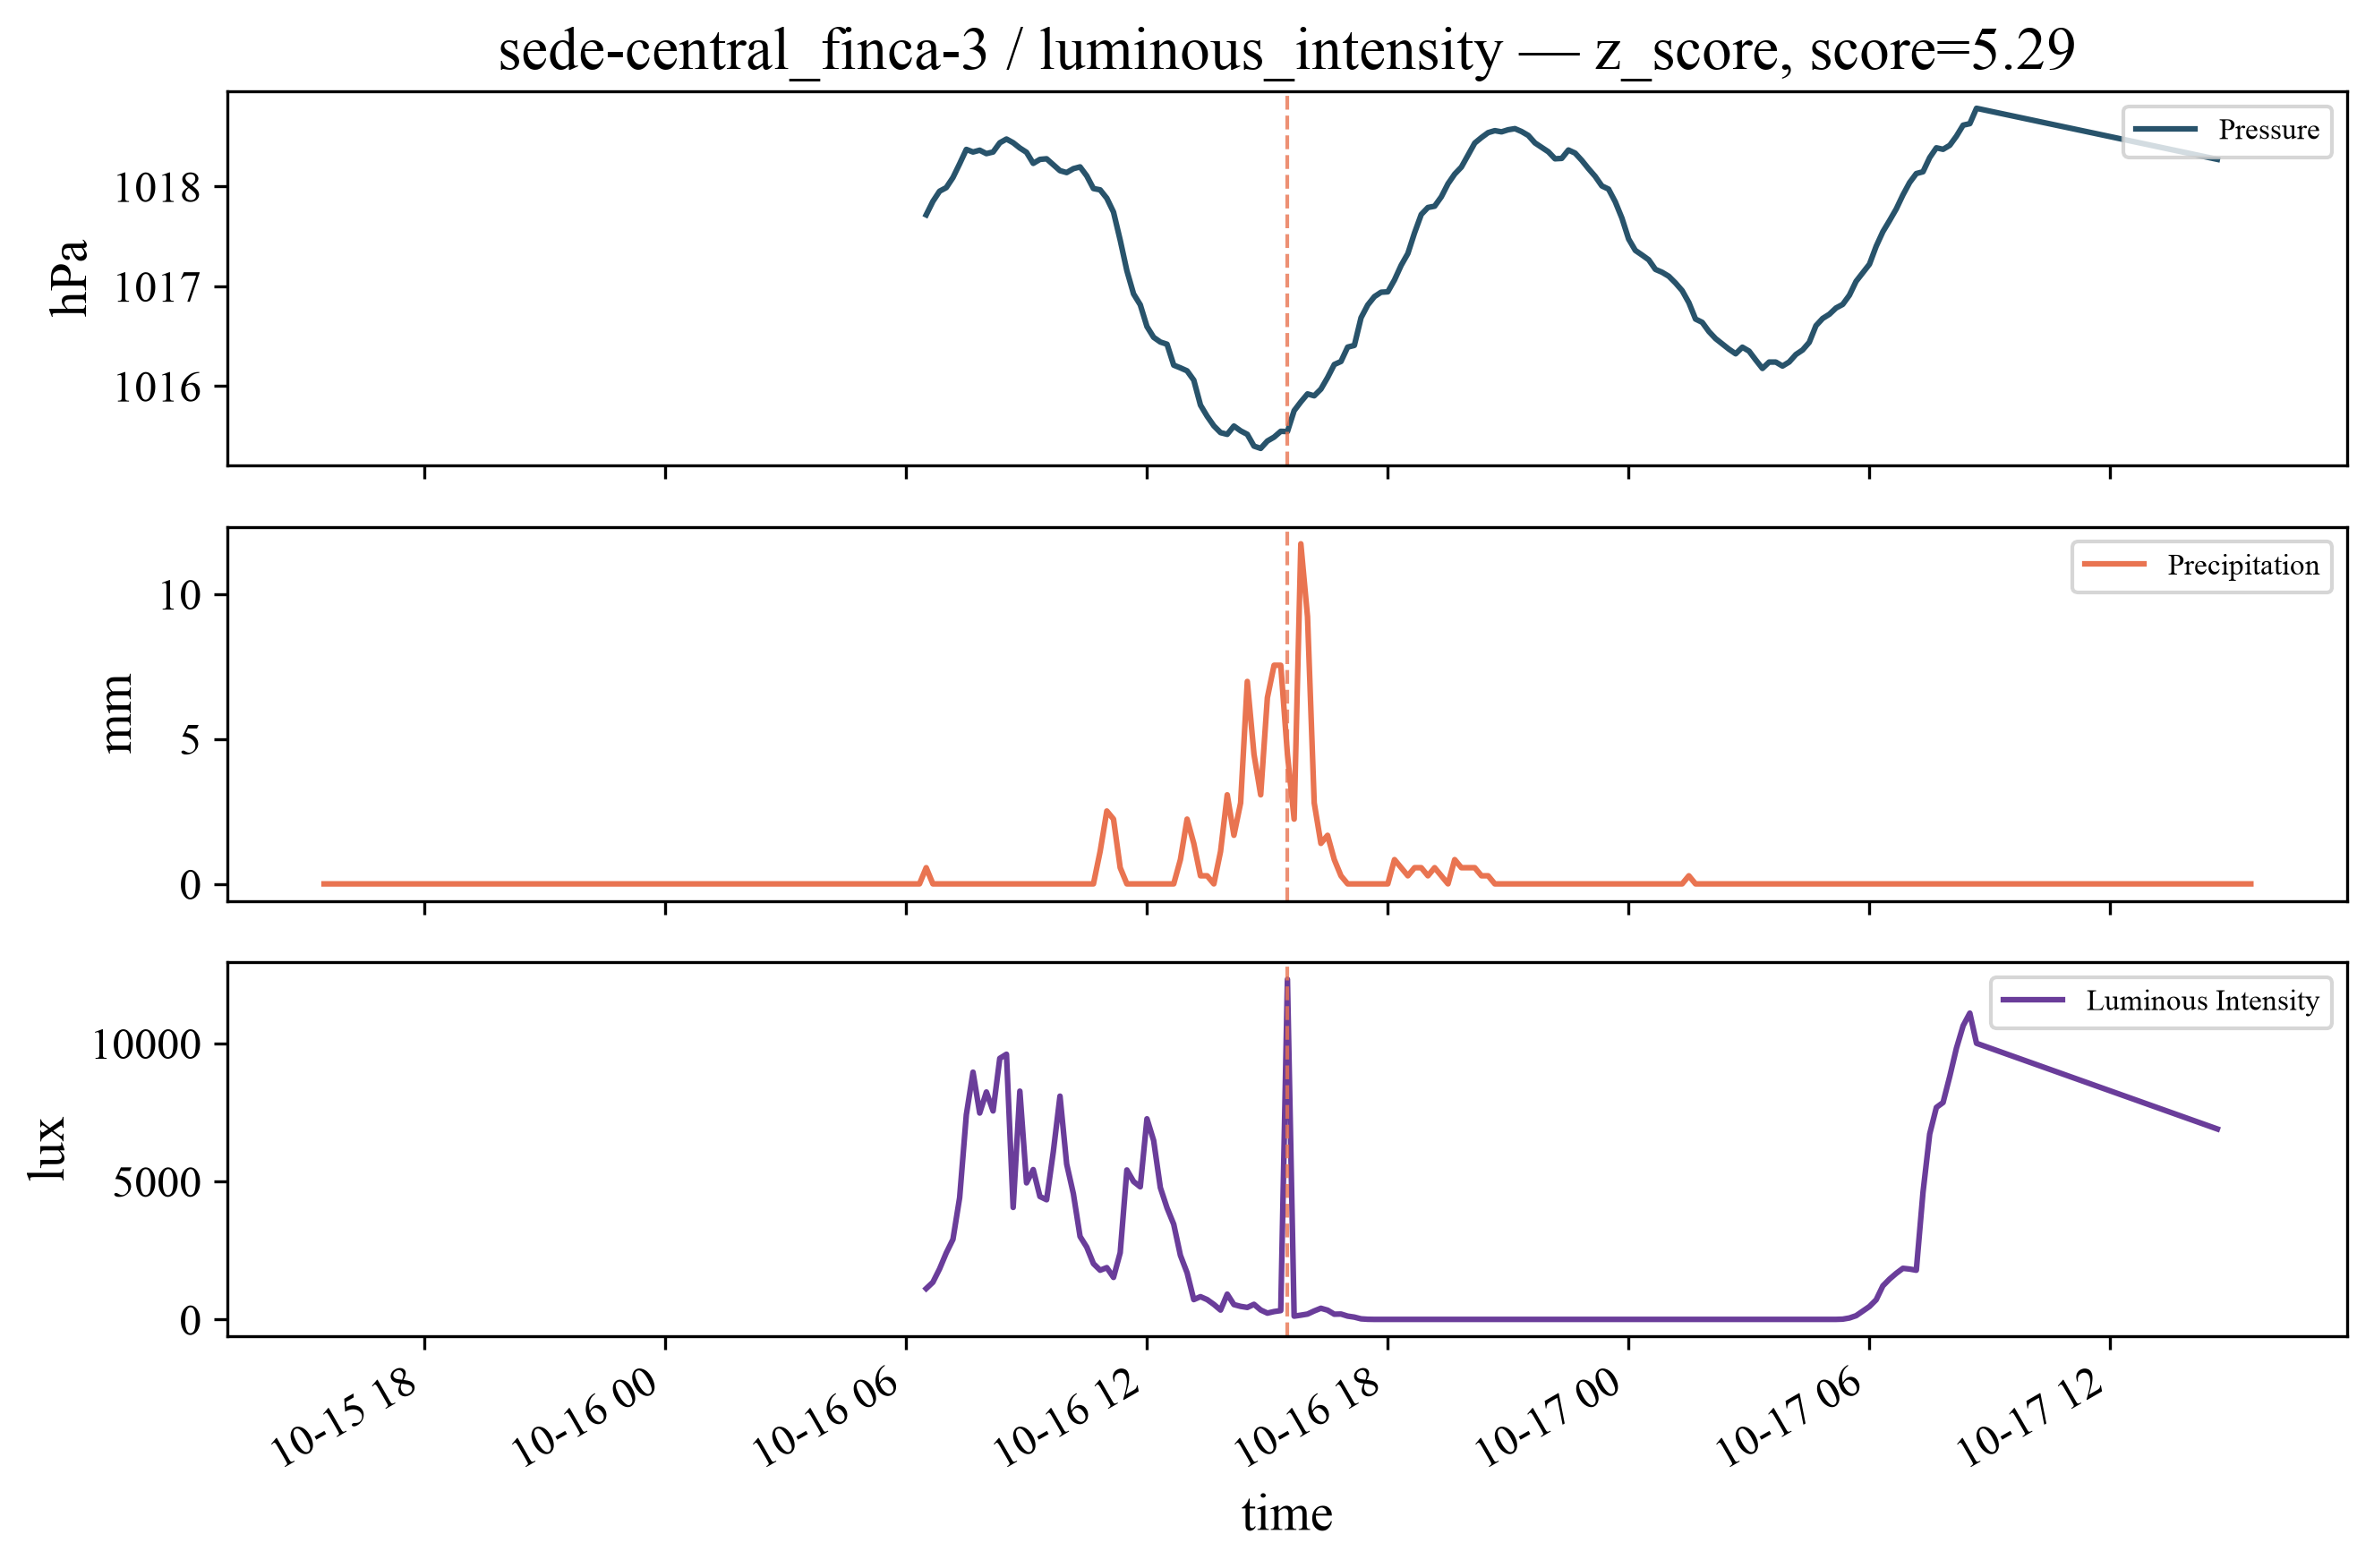

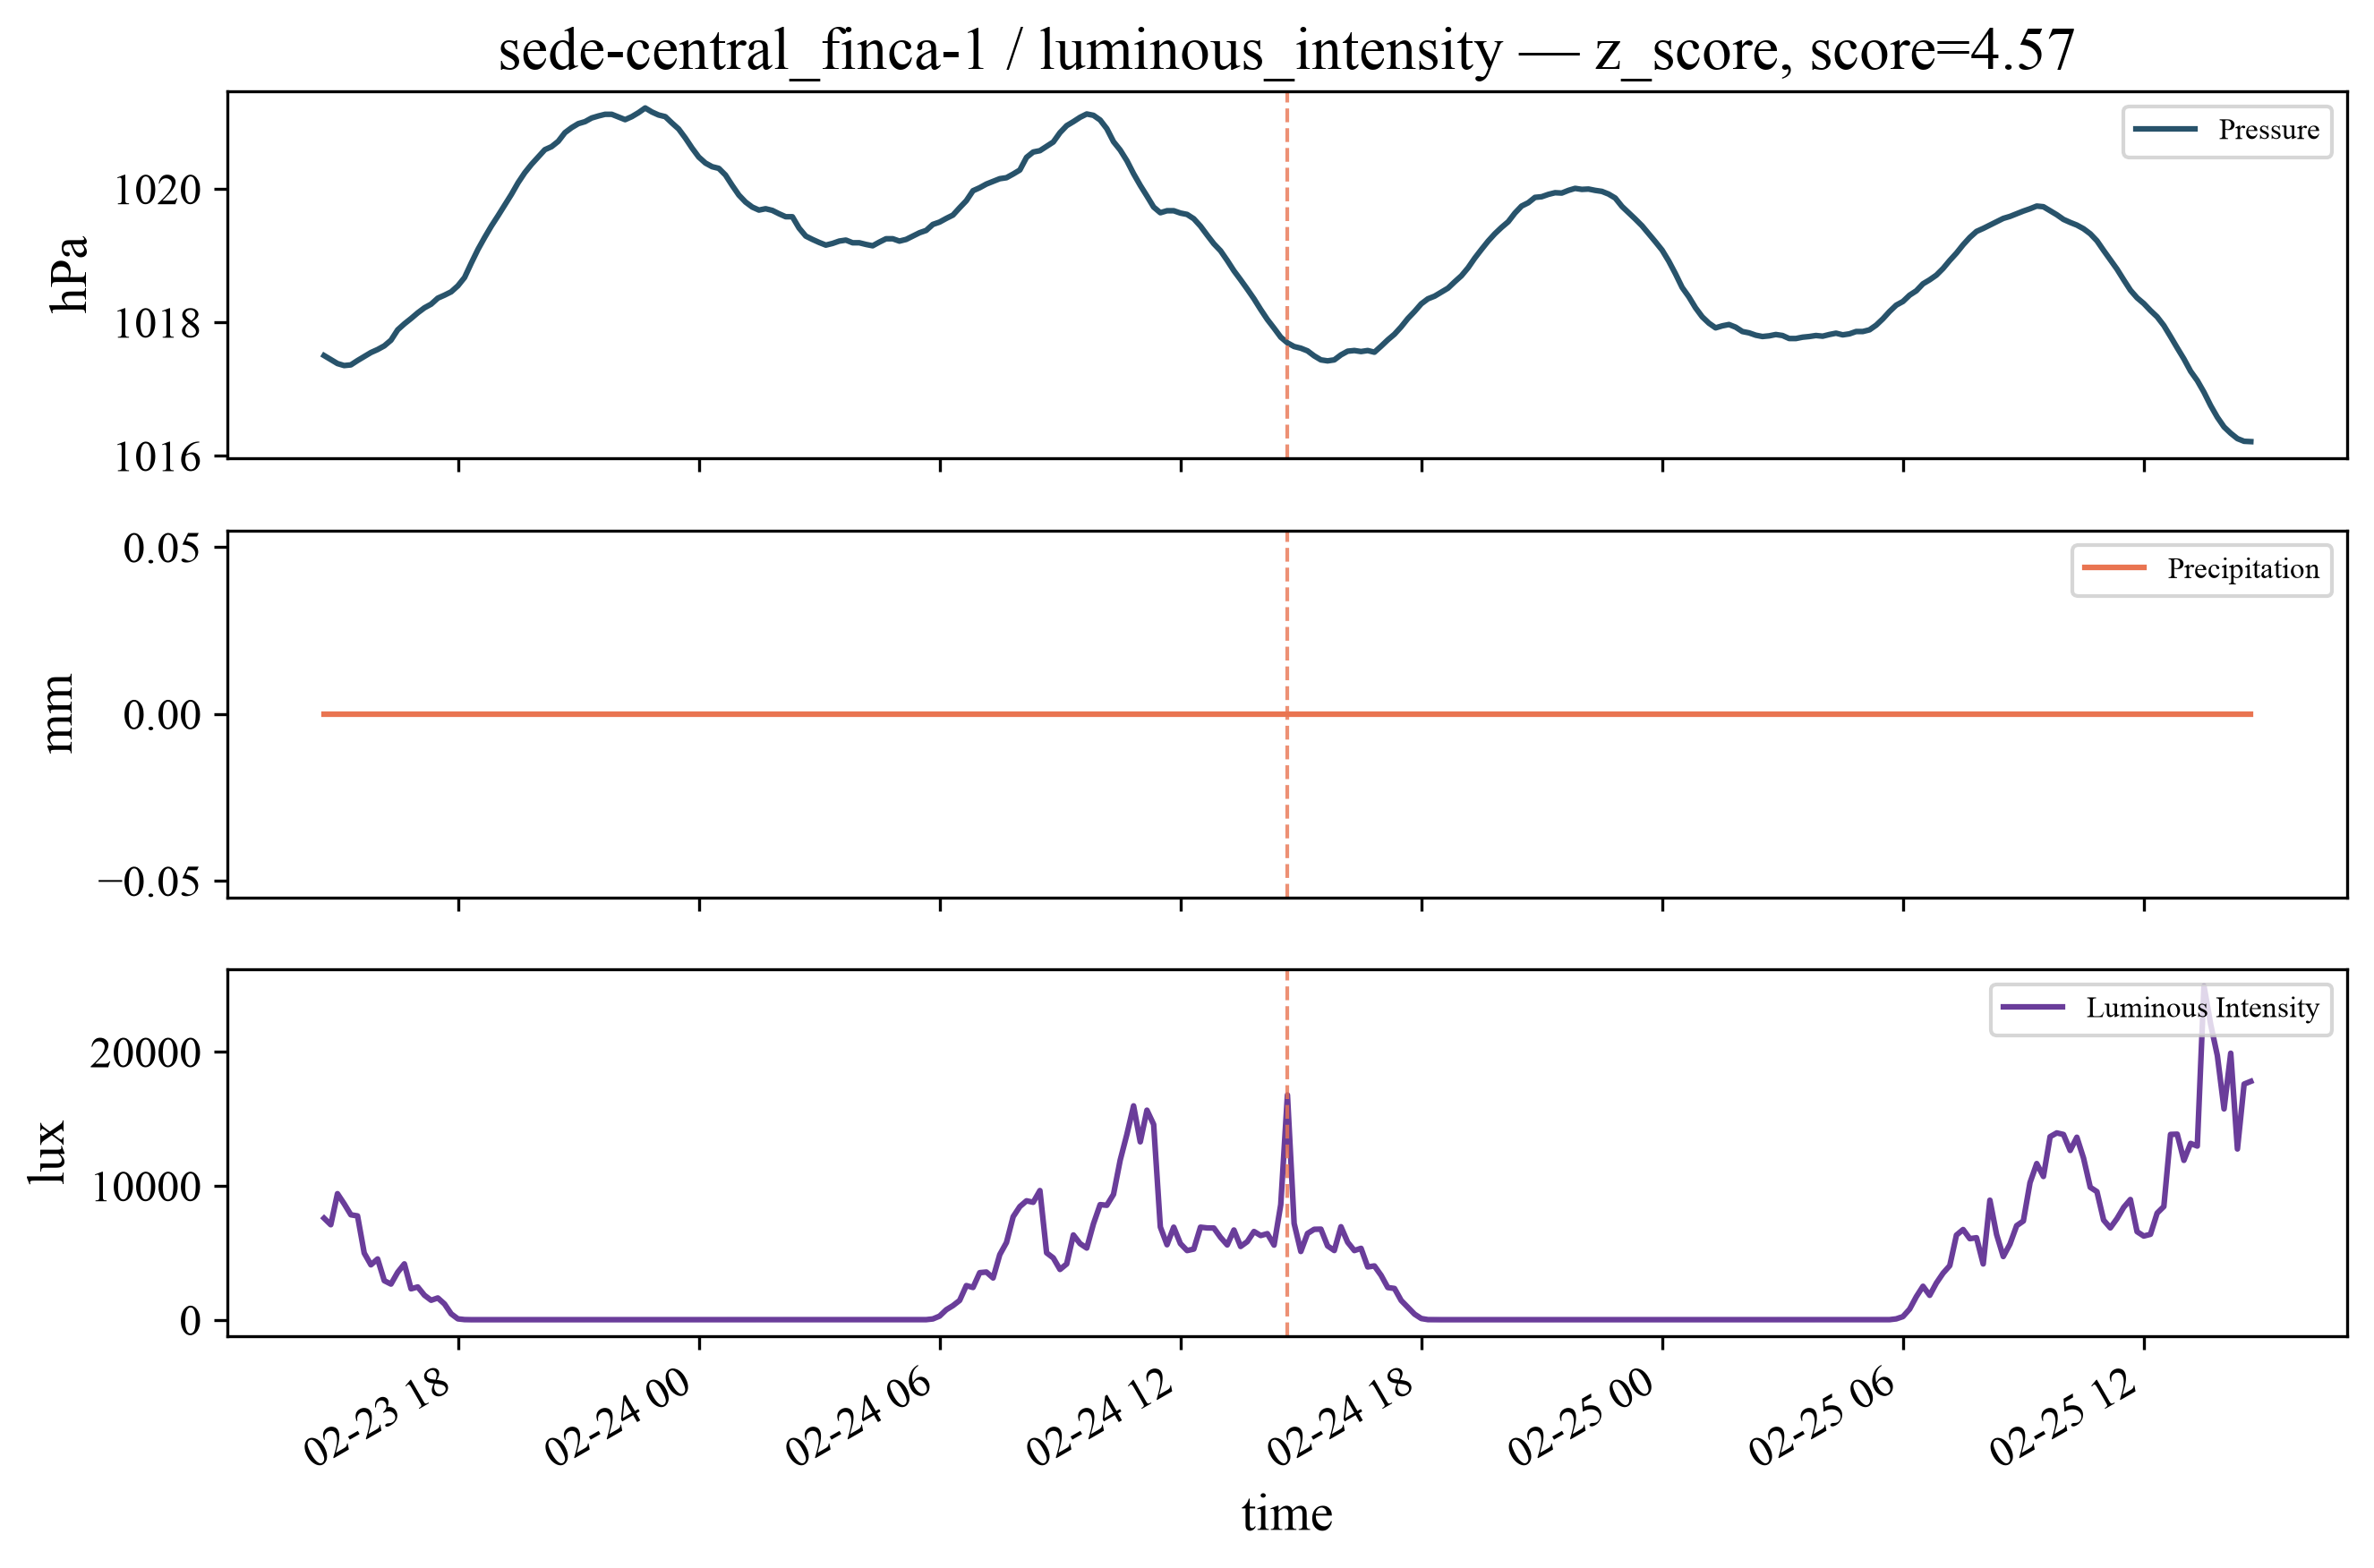

In [5]:
def plot_flagged(station: str, sensor: str, center, score, method: str, half_span=pd.Timedelta("24h")):
    df10 = station_frames[station]
    window = df10.loc[center - half_span : center + half_span]
    fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
    cols = ["pressure", "precipitation", "luminous_intensity"]
    units = {"pressure": "hPa", "precipitation": "mm", "luminous_intensity": "lux"}
    for ax, col, color_name in zip(axes, cols, PALETTE_ORDER):
        ax.plot(window.index, window[col], color=PALETTE[color_name], label=pretty_label(col))
        ax.axvline(center, color=PALETTE["burnt_sienna"], linestyle="--", linewidth=1, alpha=0.8)
        ax.set_ylabel(units[col])
        ax.legend(loc="upper right", fontsize=8)
    axes[0].set_title(f"{station} / {sensor} — {method}, score={score:.2f}")
    axes[-1].set_xlabel("time")
    fig.autofmt_xdate()
    fig.tight_layout()
    return fig


flagged_z = detections[(detections["method"] == "z_score") & detections["flagged"]].copy()
flagged_z["abs_score"] = flagged_z["score"].abs()
top_per_sensor = flagged_z.sort_values("abs_score", ascending=False).groupby("sensor").head(2)

for _, row in top_per_sensor.iterrows():
    plot_flagged(row["station"], row["sensor"], row["timestamp"], row["score"], "z_score")
    plt.show()


## Closing note

This notebook establishes the shared detection-table schema and the first
of five method families. Nothing here is validated against ground truth —
there is none — and the flagged-rate/plot checks above are only a
sanity check that the detector behaves sensibly, not evidence for any
claim about real anomalies. Steps 4-6 must write to
`reports/detections/` using this same schema (`uema.detect.SCHEMA_COLUMNS`)
so Step 7 can concatenate all five (or six, once Modified Z-score and both
LSTM/GRU variants are counted separately) methods' tables and compare them
directly.
